In [1]:
%load_ext autoreload
%autoreload 2

In [133]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from mad.configs import EARTH_SETTINGS, tomahawk, aster_30 
from mad.objs import Planet, PlanetConfig
from mad.objs import CruiseMissile, CruiseMissileConfig
from mad.guidances import CruiseWaypointGuidance, ProportionalNavigation, PurePursuit
from mad.simulation import Simulation
from mad.utils.logger import SourceLogger
from mad.utils.plotters import plot_2D_planet_with_points

logger = SourceLogger()


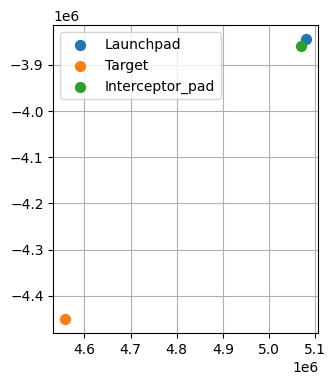

In [145]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

launchsite_target_distance_km = 800
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.random_point_at_surface(name="Launchpad", altitude=100)
interceptor_pad = earth.point_at_distance(launchpad, distance_km=20, name="Interceptor_pad")
target = earth.point_at_distance(launchpad, distance_km=launchsite_target_distance_km, name="Target")
waypoints = [launchpad, target]
plot_2D_planet_with_points(earth, points = waypoints + [interceptor_pad], display="arc");

In [146]:
tom_guidance = CruiseWaypointGuidance(planet = earth, 
                                      target=target, 
                                      waypoints=waypoints)

tomahawk_missile = CruiseMissile(position=launchpad.position.copy(), 
                                 config=CruiseMissileConfig(**tomahawk, guidance=tom_guidance))

aster_guidance = ProportionalNavigation(planet=earth, 
                                        target=tomahawk_missile, 
                                        N=5,
                                        activation_altitude_km=None,
                                        activation_range_km=50)
aster_missile = CruiseMissile(position=interceptor_pad.position.copy(), 
                              config=CruiseMissileConfig(**aster_30, guidance=aster_guidance))


21:18:14 | INFO     | Guidance     | CruiseWaypointGuidance: spline built over 2 waypoints (5 dense points), total arc length 800.0 km.


In [147]:
dt = 0.5
max_time = 5_000.0  # enough for 10 000 km at ~250 m/s

sim = Simulation(max_time=max_time, dt=dt)
sim.run(
    planet=earth,
    moving_objs=[aster_missile, tomahawk_missile],
)

df = sim.results


21:18:14 | INFO     | Simulation   | Starting simulation.
21:18:14 | INFO     | Guidance     | PN armed at altitude 0.0 km, range 20.0 km.
21:18:15 | INFO     | Missile      | ASTER-30 hit the ground.
21:18:17 | INFO     | Guidance     | Tomahawk reached terminal range (55 m from target).
21:18:17 | INFO     | Missile      | Tomahawk hit the ground.
21:18:17 | INFO     | Simulation   | Simulation ended at 2887.50s. Took 2.61 s of real time.


In [148]:
df["altitude_km"] = df["position"].apply(lambda pos: (np.linalg.norm(pos) - earth.radius) / 1e3)
df["energy_kJ"] = df["speed"].apply(lambda speed: 0.5 * speed**2 / 1e3)
df["gamma_deg"] = df["gamma"].apply(lambda g: np.degrees(g) if g is not None else None)
df = df.sort_values(by=["name", "time"])

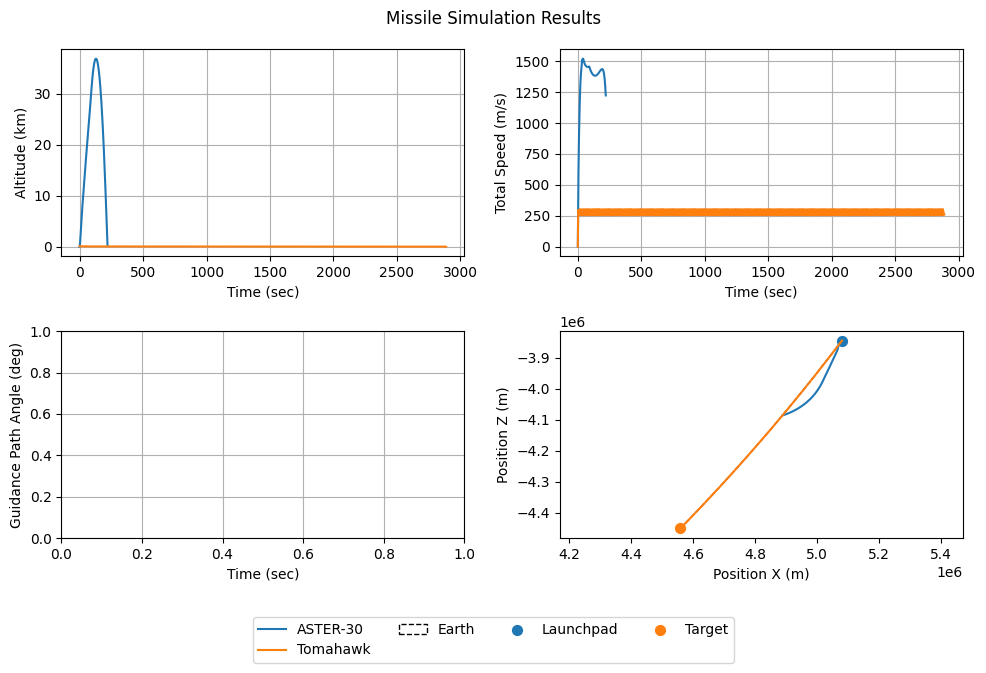

In [149]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 6))
ax = ax.ravel()

sns.lineplot(data=df, x="time", y="altitude_km", hue="name", ax=ax[0])
sns.lineplot(data=df, x="time", y="speed", hue="name", ax=ax[1])
sns.lineplot(data=df, x="time", y="gamma_deg", hue="name", ax=ax[2])
sns.lineplot(data=df, x="posx", y="posz", hue="name", ax=ax[3], sort=False, errorbar=None)

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")

ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Guidance Path Angle (deg)")

plot_2D_planet_with_points(earth, points = [launchpad, target], ax=ax[3], display="arc")
ax[3].set_xlabel("Position X (m)")
ax[3].set_ylabel("Position Z (m)")
ax[3].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()
    handles, labels = a.get_legend_handles_labels()
    a.legend().remove()

fig.suptitle("Missile Simulation Results")
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(pad=1.2)

19.84167571639081

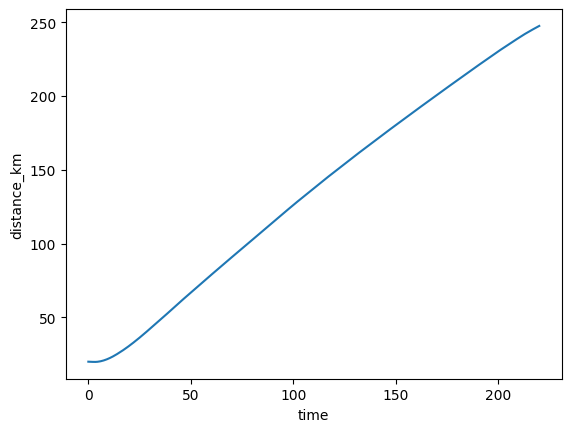

In [150]:
def distance_between_objects(df, obj1_name, obj2_name):
    df1 = df[df["name"] == obj1_name].set_index("time")
    df2 = df[df["name"] == obj2_name].set_index("time")
    common_times = df1.index.intersection(df2.index)
    df1_common = df1.loc[common_times]
    df2_common = df2.loc[common_times]
    dist_x = df1_common["posx"] - df2_common["posx"]
    dist_z = df1_common["posz"] - df2_common["posz"]
    distances = np.sqrt(dist_x**2 + dist_z**2)
    return pd.DataFrame({"time": common_times, "distance_m": distances})

distance_df = distance_between_objects(df, "ASTER-30", "Tomahawk")
distance_df["distance_km"] = distance_df["distance_m"] / 1000.0
sns.lineplot(data=distance_df, x="time", y="distance_km")

min(distance_df["distance_km"])